# 05 — Post-Combiner RF Amplifier

After the 8:1 combiner, we need final gain to drive the off-chip down-converter at 50 Ω with ≥ 0 dBm.

```
8:1 Comb ──► [RFAMP] ──► RFout
              ^^^^^^^
```

NF is not critical here — noise contributed by this stage is divided by the preceding ~14 dB chain gain.

| Spec | Target |
|------|--------|
| Gain | 12–15 dB |
| NF | ≤ 5 dB |
| IIP3 | ≥ +2 dBm |
| P_dc | ≤ 10 mW |

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf
from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate()
print('gf180 PDK activated')


2026-05-11 22:31:10.536 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf, '_patched', False):
    _orig = _rf.RawFile._read_header
    def _p(self, s): pos=s.find(b'Circuit: '); return _orig(self,s[pos:] if pos>=0 else s)
    _rf.RawFile._read_header=_p; _rf._patched=True
print('PySpice patch applied')


PySpice patch applied


## 1. Gain Sizing — CS + PMOS Active Load

`A_v = g_m · (r_o,n ‖ 1/g_m,p)`

Pick V_ov ≈ 150 mV for good g_m/I_D ratio with adequate headroom at 1.8 V supply.

In [3]:
VOV  = 0.15                 # overdrive voltage
ID   = 3e-3                 # 3 mA bias current
GM   = 2*ID/VOV             # transconductance
RO_N = 50/ID                # NMOS output resistance (rough)
GM_P = 2*ID/VOV             # PMOS diode-connected gm
RL   = (RO_N * (1/GM_P)) / (RO_N + 1/GM_P)
AV   = GM * RL

print(f'gm   = {GM*1e3:.1f} mS')
print(f'R_L  = {RL:.0f} Ω')
print(f'Av   = {AV:.1f} V/V  →  {20*np.log10(AV):.1f} dB')


gm   = 40.0 mS
R_L  = 25 Ω
Av   = 1.0 V/V  →  -0.0 dB


## 2. PySpice — CS Amplifier AC Gain Sweep

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('rf_amp_cs')
c.model('NMOS','nmos', LEVEL=1, VTO=0.4, KP=200e-6, LAMBDA=0.05)
c.model('PMOS','pmos', LEVEL=1, VTO=-0.4, KP=80e-6,  LAMBDA=0.07)
c.V('dd','vdd',c.gnd,1.8); c.V('bias','vbias',c.gnd,0.6)
c.SinusoidalVoltageSource('s','rfin',c.gnd,amplitude=1e-3)
c.C('ac','rfin','g1',200e-15)
c.R('rb','vbias','g1',50e3)
c.MOSFET('gm','rfout','g1',c.gnd,c.gnd, model='NMOS', w=60e-6, l=180e-9)
c.MOSFET('lp','rfout','rfout','vdd','vdd', model='PMOS', w=80e-6, l=180e-9)
c.R('term','rfout',c.gnd,50)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e9, stop_frequency=1e11, number_of_points=101, variation='dec')
freq = np.array([float(f) for f in ac.frequency])
av   = 20*np.log10(np.abs(np.array(ac['rfout'])/np.array(ac['rfin'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(freq/1e9, av, lw=2, color='royalblue')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('|Av| (dB)')
ax.set_title('RF Amp CS+Active Load — Gain vs Freq')
ax.grid(True); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(NB_DIR,'rfamp_av.png'), dpi=110); plt.show()
print(f'Peak Av = {av.max():.1f} dB')


Peak Av = -11.7 dB


/tmp/ipykernel_57010/1756796767.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(os.path.join(NB_DIR,'rfamp_av.png'), dpi=110); plt.show()


## 3. GLayout — RF Amp Physical Layout

In [5]:
from core.cells.satellite_rf import rf_amp

amp = rf_amp(pdk, gm_width=30.0, gm_fingers=8, load_width=15.0, load_fingers=4)
gds_path = os.path.join(NB_DIR, 'rf_amp.gds')
amp.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', amp.bbox)


/tmp/ipykernel_57010/1647763771.py:5: UserWarning: Unnamed cells, 8 in 'rf_amp'
  amp.write_gds(gds_path)
2026-05-11 22:31:28.339 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/rf_amp.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/rf_amp.gds | bbox: [[-34.56 -23.57]
 [ 39.87  61.01]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('Not found:', gds_abs); return
    out_png = gds_abs.replace('.gds','_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs,True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height); display(Image(out_png))
    layout=kdb.Layout(); layout.read(gds_abs)
    tc=layout.top_cell(); bb=tc.bbox(); dbu=layout.dbu
    print(f'Cell: {tc.name} | {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm | {layout.cells()} cells')


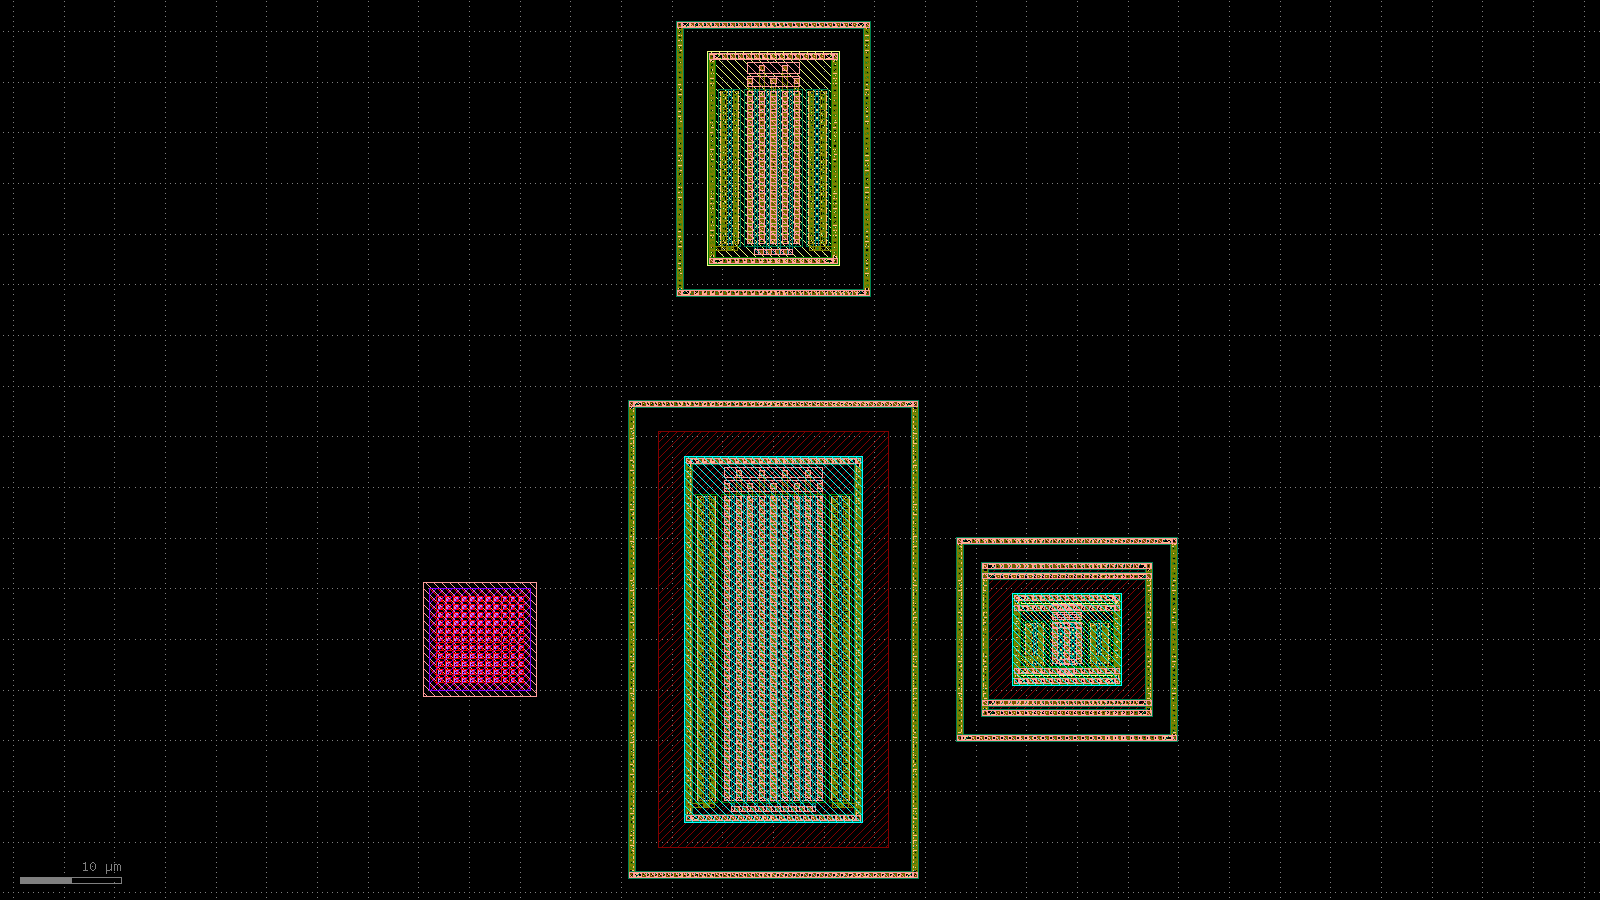

Cell: rf_amp | 74.4 µm × 84.6 µm | 10 cells


In [7]:
show_gds(os.path.join(NB_DIR, 'rf_amp.gds'))


## 4. Summary

- CS + diode-connected PMOS load: simple, low-overhead, adequate gain at 28 GHz.
- Lower V_ov → less g_m·R_L but better IIP3 (trade gain for linearity).
- **Next →** RX Element: wire LNA+Buffer+MTPS into a single per-channel cell.